# ERA V5 · Session 11 — optimizers and learning-rate schedules, measured

Every number below is computed live. The full run (300 steps, 8-point sweeps) is in `run.log` and `README.md`;
this notebook uses shorter runs so it finishes in a few minutes.

In [1]:
import os, sys
if not os.path.exists('optimizers.py'):              # on Colab: fetch the code
    !pip -q install tiktoken
    !git clone -q https://github.com/sandeepkunkunuru/era-v5.git 2>/dev/null || true
    os.chdir('era-v5/session-11-optimizers')
sys.path.insert(0, os.getcwd())
import torch, optimizers as H
from IPython.display import Image, display
import matplotlib; matplotlib.use('Agg')
_save = H._save
def _save_nb(fig, name):                              # keep the full run's figures untouched
    return _save(fig, 'notebook_' + name)
H._save = _save_nb
print('torch', torch.__version__, '| device', H.DEV)
train_ids, val = H.token_splits()

torch 2.12.1+cu130 | device cuda


## 1. Adam by hand — one weight, five gradients, checked against PyTorch

In [2]:
r1 = H.req1()

1. Adam by hand: one weight, five gradients


  w0 = 1.0, eta = 0.001, beta1 = 0.9, beta2 = 0.999, eps = 1e-8 -- the brief's Section 6 example


   t     g          m            v      m_hat      v_hat          step           w


   1  0.50   0.050000  0.000250000   0.500000   0.250000  -0.001000000 0.999000000


   2  0.40   0.085000  0.000409750   0.447368   0.204977  -0.000988126 0.998011874


...

   4  0.45   0.167850  0.000971071   0.488078   0.243132  -0.000989847 0.996027887


   5  0.55   0.206065  0.001272600   0.503199   0.255030  -0.000996425 0.995031463


  torch.optim.Adam in float64  worst |hand - torch| per quantity: m 2.8e-17, v 2.2e-19, m_hat 1.1e-16, v_hat 5.6e-17, step 4.8e-17, w 0.0e+00


  torch.optim.Adam in float32  worst |hand - torch| per quantity: m 2.6e-09, v 7.2e-11, m_hat 7.7e-09, v_hat 1.5e-08, step 1.4e-08, w 1.3e-08


  against the brief's printed table: 30 of 30 values reproduce


## 2. Bias correction switched off

2. Bias correction switched off


  constant gradient: corrected Adam steps exactly eta every time; uncorrected steps


  eta * (1 - b1^t) / sqrt(1 - b2^t). The m bias shrinks the step, the v bias inflates it,


  and with b2 = 0.999 the v bias wins for thousands of steps.


  step size / eta, first 20 steps:


...

  The ratio is exact for ANY gradient sequence, not just a constant one: both versions divide the same


  m by the same sqrt(v), so step for step they differ by exactly (1 - b1^t) / sqrt(1 - b2^t) (eps aside).


  the switchable AdamW, checked first: 20 steps against torch.optim.AdamW, worst loss difference 8.9e-05


  no warmup       final held-out loss: corrected 5.7726, uncorrected 6.0092; training curves never back within 1% inside the run (largest gap 9.3%)


  30-step warmup  final held-out loss: corrected 5.6428, uncorrected 5.9588; training curves never back within 1% inside the run (largest gap 17.6%)


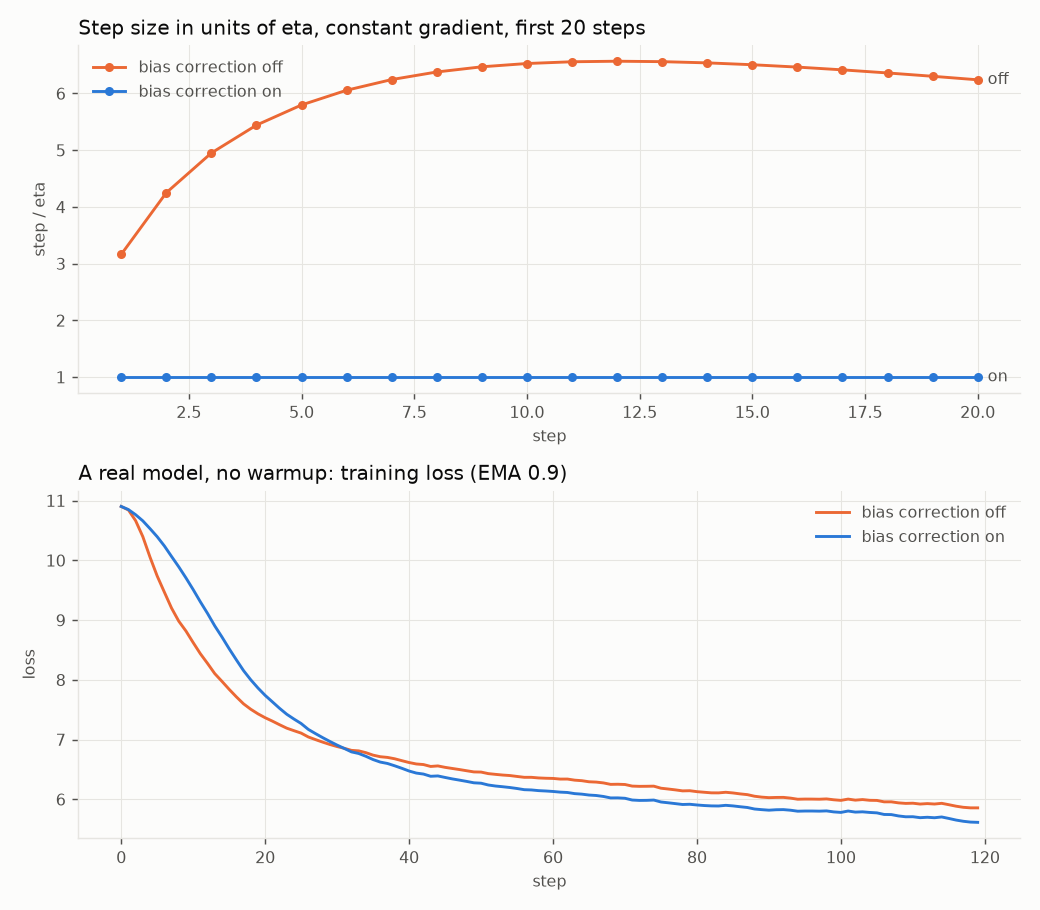

In [3]:
r2 = H.req2(train_ids, val, steps=120)
display(Image(filename=r2['figure']))

## 3. The update-to-weight ratio, every layer

3. The update-to-weight ratio, every layer, every step


  ||delta w|| / ||w|| per weight matrix, peak lr 1e-3, 160 steps; linear warmup over 60 steps


  against the same run with no warmup. Clipping at 1.0 in both.


  layer                             max, no warmup  max, warmup   last 20  warmup stops mattering


  wte.weight                              4.92e-02     2.37e-02  4.64e-03      never (within run)


...

  blocks.3.ffn.down.weight                4.99e-02     1.12e-02  1.07e-02      never (within run)


  largest ratio anywhere: 5.03e-02 without warmup, 2.37e-02 with it (2.1x smaller)


  rule: the median over all 22 layers of ratio(warmup) / ratio(no warmup), each smoothed with a


  9-step rolling median, stays within 10% of 1 from that step on.


  -> warmup stops changing the update-to-weight ratio at step None (warmup itself ends at step 60); 2 of 22 layers also pass the rule individually


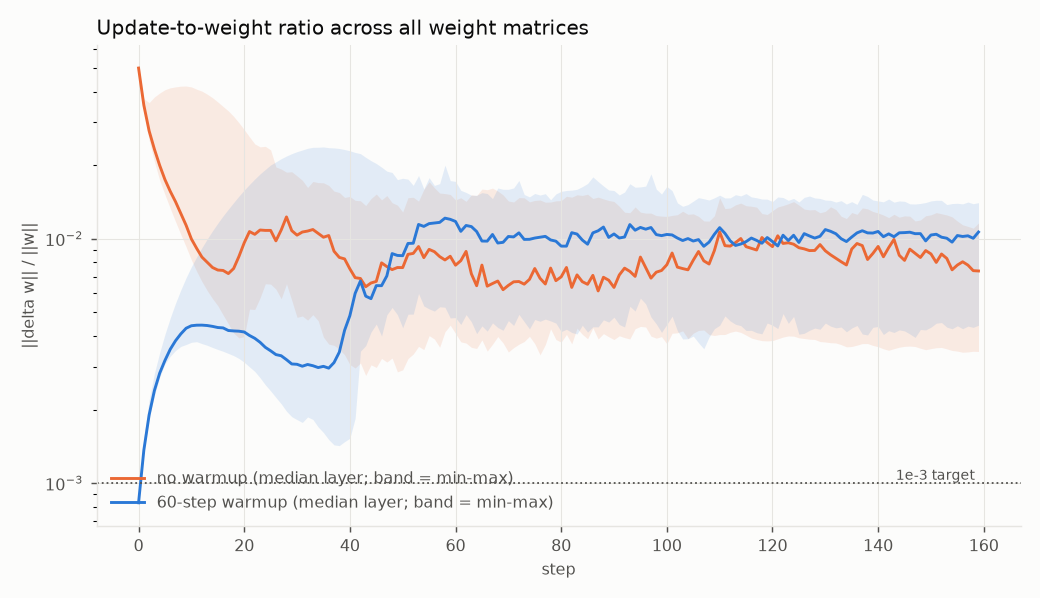

In [4]:
r3 = H.req3(train_ids, val, steps=160, warm=60)
display(Image(filename=r3['figure']))

## 4. Cosine against WSD, both tuned, stopped at step 200

4. Cosine against WSD: 300-step schedules, both stopped at step 200


  both schedules defined for 300 steps with a 30-step warmup; WSD decays over the last 20%


  (steps 240-300). Stopped at 200: cosine is at 0.38x its peak, WSD at 1.00x -- it has not started to decay.


  tune both sides: peak learning rate swept over [0.0005, 0.001, 0.002] for each schedule first.


   peak lr  cosine @200   WSD @200


...

     2e-03       5.4492     5.4614


  tuned: cosine best at 1e-03 -> 5.2390;  WSD best at 1e-03 -> 5.1894


  WSD step-200 checkpoint + a 20-step decay branch (10% more steps): 5.1162


  reference: cosine scheduled for exactly 200 steps (knowing the length in advance): 5.3886


  stopped at 200 with no further compute, the lower held-out loss is WSD's (5.1894 vs 5.2390).


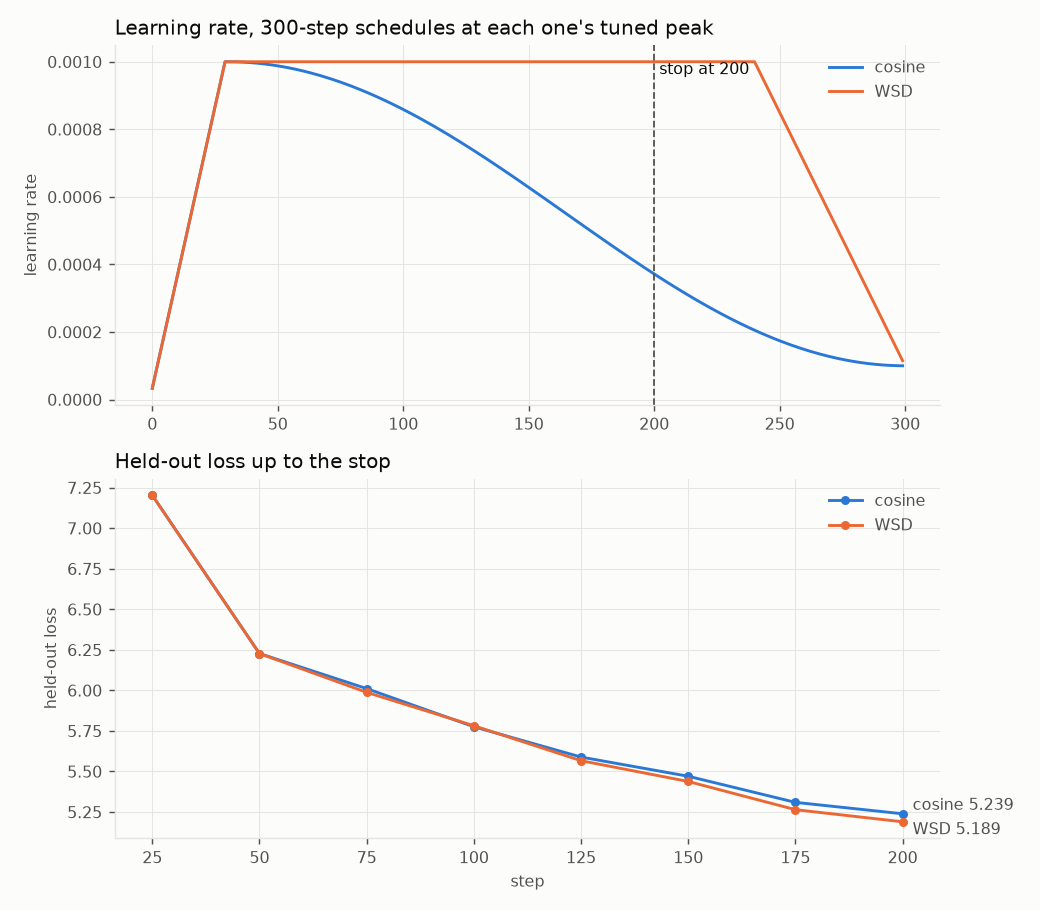

In [5]:
r4 = H.req4(train_ids, val, quick=True)
display(Image(filename=r4['figure']))

## 5. Learning-rate sweep at widths 256, 512 and 1,024

`quick=True` uses 3 learning rates and 120 steps; the full 8-point, 300-step sweep is in the README.

5. Learning-rate sweep at widths 256, 512 and 1,024


  4 layers, head dim 64, standard parameterization (init std 0.02 at every width), batch 16x128,


  120 steps (30 warmup, cosine to 10%), one seed. Loss = held-out, token-weighted.


    peak lr     w=256     w=512    w=1024


    2.0e-04    6.6162    5.9769    5.6733


...

  width   256: grid minimum 8.0e-04 (loss 5.8224), parabola in log-lr 1.45e-03


  width   512: grid minimum 8.0e-04 (loss 5.7112), parabola in log-lr 9.77e-04


  width  1024: grid minimum 8.0e-04 (loss 5.4713), parabola in log-lr 6.34e-04


  fitted lr* ~ width^-0.60. Extrapolated to width 4,096: 2.8e-04


  the two width doublings alone give exponents -0.57 and -0.62 -> 2.7e-04 to 2.9e-04 at 4,096


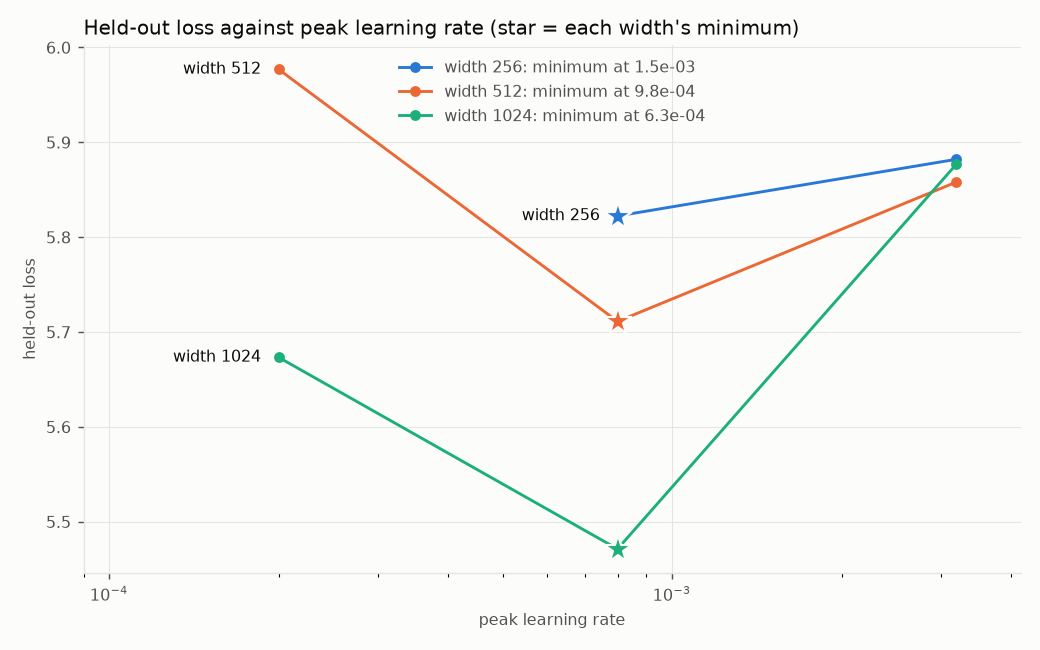

In [6]:
r5 = H.req5(train_ids, val, quick=True)
display(Image(filename=r5['figure']))